# Tour of the Solar System
In this notebook, you will walk through the basic of components of the Solar System and get your hands dirty with some data. The goal is to get a general sense of the architecture of the Solar System, the major bodies, and the basic compositions of various objects. You'll be asked to make some conjectures about what some of the data implies. In many scenarios, there won't be a single right answer because planetary scientists are still trying to figure a lot of this stuff out! The Solar System provides us with the highest quality data from which to answer questions about planet habitability, formation, evolution, etc. However, it is a single system, i.e., a sample size of  $N=1$. Fortunately, nature provides us with a large sample of exoplanets from which to study the diversity of planets and planetary systems. This notebook will set the stage for some interesting questions that we will circle back to throughout the course as we learn more and more about exoplanets and try to place our system in the broader context.

#### Aknowledgements
Notebook Author: Joe Schulze <sup id="fnref1"><a href="#fn1">1</a></sup>
<p id="fn1"><sup>1</sup> Department of Physics & Astronomy, Louisiana State University</p></div>

In [2]:
import sys
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

sys.path.insert(1, os.path.abspath('../general_functions'))
from nb_toc import toc, setup
setup()

toc(["A birds eye view of the Solar System",
    "The planets",
    "Planet discussion plots",
    "Scaling densities",
    "Satellites",
    "Limits for Jupiter's moons",
    "Limits for Saturn's moons",
    "The 'Potato Radius'"])

<IPython.core.display.Javascript object>

## A birds eye view of the Solar System
![solar_sys_schematic.png](./figures/solar_sys_schematic.png)

## The planets

### Planet data and unit conversions
The code cell below loads in the planet data provided here https://devstronomy.martinovo.net/#/datasets#satellites. This dataset contains a larger number of parameters. For the purpose of this notebook, we will focus predominantly on mass, radius, density, and distance from Sun. However, you are welcome to and encourage to play around with any of the other parameters you think might be interesting!

After the data is loaded, there are a few unit conversions that are useful to know for this course and (exo)planetary science at large. Discuss with your group what the final units are and why we might want to deal in these units. 

**Disclaimer**: the original data file does not contain information about the parameter units. Instead they are listed in a table of the devstronomy page linked above. You will need to look at this table in order to determine the initial units and understand the conversions being made below.


In [6]:
planets = pd.read_csv('./data/planets.csv')
#this next line of code removes pluto from the planet sample b/c pluto is not a planet. 
#Comment the line below out if you disagree!
planets = planets.iloc[np.where(planets['planet'] != 'Pluto')]

In [7]:
au = 1.496e+8 #km
re = 6371.0 #average radius of the Earth in km
planets['mass'] = planets['mass']/5.97
planets['distance_from_sun'] = planets['distance_from_sun']*(10**6) / au
planets['radius'] = planets['diameter']/2.0/re
planets['mean_temperature'] = planets['mean_temperature'] + 273.15

print('Radius of Earth: ', planets['radius'].iloc[2], r'$R_\oplus$')

Radius of Earth:  1.0010987286140323 $R_\oplus$


**Spoiler**: one of the conversions scales scales planet radii to the average radius of Earth (6371 km) so that all radii are in units of $R_\oplus$. The newly scaled Earth radius is printed above in $R_\oplus$ units. The output should ideally be exactly 1, but it's not. Nor is it some sort of rounding error. Hmm. The data file gives a diameter of 12756 km for Earth which corresponds to a radius of 6378 km. This is larger than the assumed 6371 km . Why are these two numbers different?

### Planet discussion plots

You don't need to worry about the wall of code below. You may find this cell to be a useful reference when you start making plots for your own purposes, depending on how intricate you want to go. For now, just run the cell and look at the output!

The terrestrial planets are circles of various colors and the gas giants are squares of different colors (feel free to change these as you see fit).

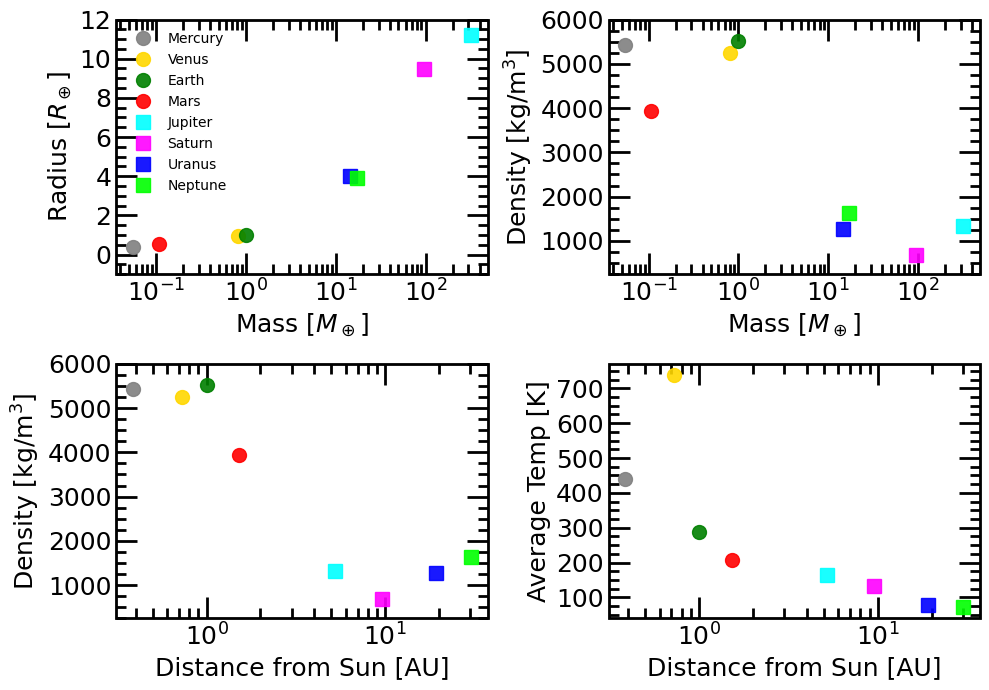

In [10]:
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
import matplotlib.ticker as ticker

#initialize figure
fig, ax = plt.subplots(2,2, figsize = (10, 7))

#symbol and color lists for the various planets.
symbol_list = ['o', 'o', 'o', 'o', 's', 's', 's', 's']
color_list = ['gray', 'gold', 'green', 'red', 'cyan', 'magenta', 'blue', 'lime']

#tick parameters
major_tick_length = 15
minor_tick_length = 7.5
tick_label_size = 18
top_ticks = True
right_ticks = True
tick_width = 2
markersize = 10
symbol_alpha = 0.9
axis_label_size = 18


#top left
for i in range(0, len(planets)):
    ax[0,0].plot(planets['mass'].iloc[i], planets['radius'].iloc[i], lw = 0, color = color_list[i],
                 marker = symbol_list[i],markersize = markersize, alpha = symbol_alpha, label = planets['planet'].iloc[i])

ax[0,0].legend(fontsize = 10, frameon = False)
ax[0,0].set_xscale('log')
ax[0,0].patch.set_edgecolor('black')  
ax[0,0].patch.set_linewidth(2)  
ax[0,0].tick_params(which = 'major', direction = 'in', length = major_tick_length, labelsize = tick_label_size, 
                     top = top_ticks,  right = right_ticks, width = tick_width)
ax[0,0].tick_params(which = 'minor', direction = 'in',length = minor_tick_length, top = top_ticks,  
                    right = right_ticks, width = tick_width)
ax[0,0].yaxis.set_major_locator(MultipleLocator(2.0))
ax[0,0].yaxis.set_major_formatter('{x:.0f}')
ax[0,0].set_ylim(-1, 12)
ax[0,0].yaxis.set_minor_locator(MultipleLocator(0.5))
ax[0,0].set_xlabel(r'Mass [$M_\oplus$]', fontsize = axis_label_size)
ax[0,0].set_ylabel(r'Radius [$R_\oplus$]', fontsize = axis_label_size)
ax[0,0].xaxis.set_major_locator(MultipleLocator(100.0))
majors = 10**np.linspace(-1, 2, 4)
ax[0,0].xaxis.set_major_locator(ticker.FixedLocator(majors))
minors = np.array([np.arange(1,10)*x for x in 10**np.linspace(-2, 3, 6)]).flatten()
ax[0,0].xaxis.set_minor_locator(ticker.FixedLocator(minors))



#top right
for i in range(0, len(planets)):
    ax[0,1].plot(planets['mass'].iloc[i], planets['density'].iloc[i], lw = 0, color = color_list[i],
                 marker = symbol_list[i],markersize = markersize, alpha = symbol_alpha)
ax[0,1].set_xscale('log')
ax[0,1].patch.set_edgecolor('black')  
ax[0,1].patch.set_linewidth(2)  
ax[0,1].tick_params(which = 'major', direction = 'in', length = major_tick_length, 
                    labelsize = tick_label_size,  top = top_ticks,  right = right_ticks, width = tick_width)
ax[0,1].tick_params(which = 'minor', direction = 'in',length = minor_tick_length,  top = top_ticks,  right = right_ticks, width = tick_width)
ax[0,1].yaxis.set_major_locator(MultipleLocator(1000.0))
ax[0,1].yaxis.set_major_formatter('{x:.0f}')
ax[0,1].set_ylim(250, 6000)
ax[0,1].yaxis.set_minor_locator(MultipleLocator(250))
ax[0,1].set_xlabel(r'Mass [$M_\oplus$]', fontsize = axis_label_size)
ax[0,1].set_ylabel(r'Density [kg/m$^3$]', fontsize = axis_label_size)
majors = 10**np.linspace(-1, 2, 4)
ax[0,1].xaxis.set_major_locator(ticker.FixedLocator(majors))
minors = np.array([np.arange(1,10)*x for x in 10**np.linspace(-2, 3, 6)]).flatten()
ax[0,1].xaxis.set_minor_locator(ticker.FixedLocator(minors))


#bottom left
for i in range(0, len(planets)):
    ax[1,0].plot(planets['distance_from_sun'].iloc[i], planets['density'].iloc[i], lw = 0, color = color_list[i],
                 marker = symbol_list[i],markersize = markersize, alpha = symbol_alpha)
ax[1,0].set_xscale('log')
ax[1,0].patch.set_edgecolor('black')  
ax[1,0].patch.set_linewidth(2)  
ax[1,0].tick_params(which = 'major', direction = 'in', length = major_tick_length, labelsize = tick_label_size,  top = top_ticks,  right = right_ticks, width = tick_width)
ax[1,0].tick_params(which = 'minor', direction = 'in',length = minor_tick_length,  top = top_ticks,  right = right_ticks, width = tick_width)
ax[1,0].yaxis.set_major_locator(MultipleLocator(1000.0))
ax[1,0].yaxis.set_major_formatter('{x:.0f}')
ax[1,0].set_ylim(250, 6000)
ax[1,0].yaxis.set_minor_locator(MultipleLocator(250))
ax[1,0].set_xlabel(r'Distance from Sun [AU]', fontsize = axis_label_size)
ax[1,0].set_ylabel(r'Density [kg/m$^3$]', fontsize = axis_label_size)
majors = 10**np.linspace(0, 1, 2)
ax[1,0].xaxis.set_major_locator(ticker.FixedLocator(majors))
minors = np.array([np.arange(1,10)*x for x in 10**np.linspace(-1, 2, 4)]).flatten()
ax[1,0].xaxis.set_minor_locator(ticker.FixedLocator(minors))

#bottom right
for i in range(0, len(planets)):
    ax[1,1].plot(planets['distance_from_sun'].iloc[i], planets['mean_temperature'].iloc[i], lw = 0, color = color_list[i],
                 marker = symbol_list[i],markersize = markersize, alpha = symbol_alpha)
ax[1,1].set_xscale('log')
ax[1,1].patch.set_edgecolor('black')  
ax[1,1].patch.set_linewidth(2)  
ax[1,1].tick_params(which = 'major', direction = 'in', length = major_tick_length, labelsize = tick_label_size,  top = top_ticks,  right = right_ticks, width = tick_width)
ax[1,1].tick_params(which = 'minor', direction = 'in',length = minor_tick_length,  top = top_ticks,  right = right_ticks, width = tick_width)
ax[1,1].yaxis.set_major_locator(MultipleLocator(100.0))
ax[1,1].yaxis.set_major_formatter('{x:.0f}')
#ax[1,1].set_ylim(250, 6000)
ax[1,1].yaxis.set_minor_locator(MultipleLocator(25))
ax[1,1].set_xlabel(r'Distance from Sun [AU]', fontsize = axis_label_size)
ax[1,1].set_ylabel(r'Average Temp [K]', fontsize = axis_label_size)
majors = 10**np.linspace(0, 1, 2)
ax[1,1].xaxis.set_major_locator(ticker.FixedLocator(majors))
minors = np.array([np.arange(1,10)*x for x in 10**np.linspace(-1, 2, 4)]).flatten()
ax[1,1].xaxis.set_minor_locator(ticker.FixedLocator(minors))


plt.tight_layout()




Discuss each plot with your classmates. To start, just make some observations about each. Are there any trends? Any clusters? Any data points that seem to deviate from an observed trend. This is not intended to be a trick question -- discuss trends that you might consider to be "obvious".

Once you made some observations, try to interpret your observations. What do you think may be driving some of the trends/features that you observe? In other words, what is the data telling you?

### Scaling densities
In the density plots, you hopefully observed two clusters of points seperating the rocky planets (Mercury, Venus, Earth, and Mars) from the gas/ice giant planets (Jupiter, Saturn, Uranus, Neptune). Density is sufficient for differentiating between planets of vastly different compositions, e.g. rock-dominated vs gas-dominated objects. 

If you want to understand differences in composition between two likely rocky planets with different masses or two gas dominated planets with different masses, however, density alone usually doesn't give you the whole picture. We will circle back to this concept later in more detail later in the course when we start building our own planets! For now, all you need to know is that when materials are "squeezed", or subject to increases in pressure, they will compress, resulting in a decrease in volume and increase in density. This means that two rocky planets that have different masses but are identical in every other way will have different densities. The more massive one will have a higher density because the rocky materials in its interior are subject to higher pressures and are therefore more compressed (on average).

With this in mind, we will normalize the planet densities relative to mass-radius-composition curves and see if we can tease out any additional information about the Solar System planets. A mass-radius-composition curve calculates the radius of a planet as a function of mass (or vice versa) for an assumed planet composition and interior structure, e.g., to zeroth order the Earth is roughly 33% iron core and 67% silicate mantle (MgSiO$_3$).

To this end, we will scale the rocky planets to a mass-radius-composition curve for Earth-like planets (calculated using [MAGRATHEA](https://github.com/Huang-CL/Magrathea)). We will scale the gas/ice giants relative to a mass-radius-composition curve for a pure H$_2$O-ice planet (calculated from [Zeng+ 2019](https://www.pnas.org/doi/epdf/10.1073/pnas.1812905116)
). Why might it be useful to scale these two types of planets differently?

In [13]:
#load in mass-radius-composition curve data
earth_ish_mrc = pd.read_csv('./data/earth_like_mrc_curve.csv')
h2o_mrc = pd.read_csv('./data/h2o_mrc_curve.csv')

#interpolate to make our lives slightly easier
import scipy.interpolate as si
rho_scaled_rock = si.interp1d(earth_ish_mrc['mass'], 5512*earth_ish_mrc['mass']/(earth_ish_mrc['radius']**3), fill_value = 'extrapolate')
rho_scaled_ice = si.interp1d(h2o_mrc['mass'], 5512*h2o_mrc['mass']/(h2o_mrc['radius']**3), fill_value = 'extrapolate')



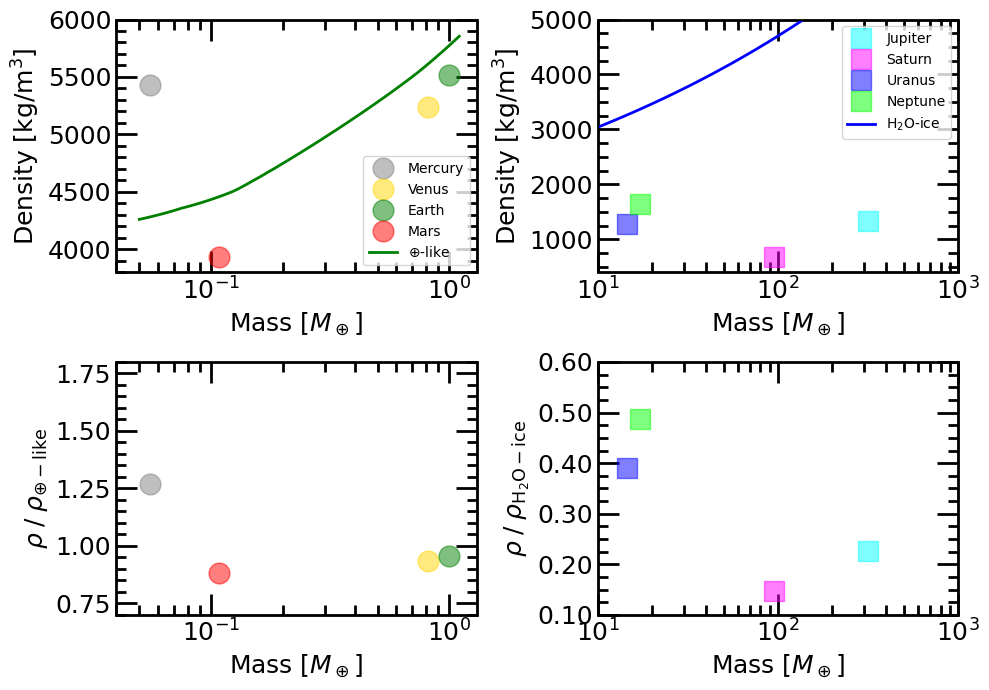

In [14]:
#initialize figure
fig, ax = plt.subplots(2,2, figsize = (10, 7))

#symbol and color lists for the various planets.
symbol_list = ['o', 'o', 'o', 'o', 's', 's', 's', 's']
color_list = ['gray', 'gold', 'green', 'red', 'cyan', 'magenta', 'blue', 'lime']

#tick parameters
major_tick_length = 15
minor_tick_length = 7.5
tick_label_size = 18
top_ticks = True
right_ticks = True
tick_width = 2
markersize = 10
symbol_alpha = 0.9
axis_label_size = 18


#top left
for i in range(0, 4):
    ax[0,0].plot(planets['mass'].iloc[i], planets['density'].iloc[i], 
                 lw = 0, color = color_list[i], marker = symbol_list[i], markersize = 15, alpha = 0.5, 
                 label = planets['planet'].iloc[i])
    
mass_array = 10**(np.linspace(np.log10(min(earth_ish_mrc['mass'])), np.log10(max(earth_ish_mrc['mass'])), 100))
ax[0,0].plot(mass_array, rho_scaled_rock(mass_array), 'g-', linewidth = 2, label = r'$\oplus$-like')

ax[0,0].legend(fontsize = 10)
ax[0,0].set_xscale('log')
ax[0,0].patch.set_edgecolor('black')  
ax[0,0].patch.set_linewidth(2)  
ax[0,0].tick_params(which = 'major', direction = 'in', length = major_tick_length, labelsize = tick_label_size, 
                     top = top_ticks,  right = right_ticks, width = tick_width)
ax[0,0].tick_params(which = 'minor', direction = 'in',length = minor_tick_length, top = top_ticks,  
                    right = right_ticks, width = tick_width)
ax[0,0].yaxis.set_major_locator(MultipleLocator(500))
ax[0,0].yaxis.set_major_formatter('{x:.0f}')
ax[0,0].set_ylim(3800, 6000)
ax[0,0].yaxis.set_minor_locator(MultipleLocator(100))
ax[0,0].set_xlabel(r'Mass [$M_\oplus$]', fontsize = axis_label_size)
ax[0,0].set_ylabel(r'Density [kg/m$^3$]', fontsize = axis_label_size)
ax[0,0].xaxis.set_major_locator(MultipleLocator(0.5))
majors = 10**np.linspace(-2, 0, 3)
ax[0,0].xaxis.set_major_locator(ticker.FixedLocator(majors))
minors = np.array([np.arange(1,10)*x for x in 10**np.linspace(-2, 0, 3)]).flatten()
ax[0,0].xaxis.set_minor_locator(ticker.FixedLocator(minors))
ax[0,0].set_xlim(0.04, 1.3)



#top right
for i in range(4, 8):
    ax[0,1].plot(planets['mass'].iloc[i], planets['density'].iloc[i], 
               lw = 0, color = color_list[i], marker = symbol_list[i], markersize = 15, alpha = 0.5, 
               label = planets['planet'].iloc[i])
mass_array = 10**(np.linspace(np.log10(min(h2o_mrc['mass'])), np.log10(max(h2o_mrc['mass'])), 100))
ax[0,1].plot(mass_array, rho_scaled_ice(mass_array), 'b-', linewidth = 2, label = r'H$_2$O-ice')

ax[0,1].legend(fontsize = 10)
ax[0,1].set_xscale('log')
ax[0,1].patch.set_edgecolor('black')  
ax[0,1].patch.set_linewidth(2)  
ax[0,1].tick_params(which = 'major', direction = 'in', length = major_tick_length, labelsize = tick_label_size, 
                     top = top_ticks,  right = right_ticks, width = tick_width)
ax[0,1].tick_params(which = 'minor', direction = 'in',length = minor_tick_length, top = top_ticks,  
                    right = right_ticks, width = tick_width)
ax[0,1].yaxis.set_major_locator(MultipleLocator(1000.0))
ax[0,1].yaxis.set_major_formatter('{x:.0f}')
ax[0,1].set_ylim(400, 5000)
ax[0,1].yaxis.set_minor_locator(MultipleLocator(250))
ax[0,1].set_xlabel(r'Mass [$M_\oplus$]', fontsize = axis_label_size)
ax[0,1].set_ylabel(r'Density [kg/m$^3$]', fontsize = axis_label_size)
majors = 10**np.linspace(1, 3, 3)
ax[0,1].xaxis.set_major_locator(ticker.FixedLocator(majors))
minors = np.array([np.arange(1,10)*x for x in 10**np.linspace(1, 3, 3)]).flatten()
ax[0,1].xaxis.set_minor_locator(ticker.FixedLocator(minors))
ax[0,1].set_xlim(10, 1000)


#bottom left
for i in range(0, 4):
    ax[1,0].plot(planets['mass'].iloc[i], planets['density'].iloc[i]/rho_scaled_rock(planets['mass'].iloc[i]), 
                 lw = 0, color = color_list[i], marker = symbol_list[i], markersize = 15, alpha = 0.5, 
                 label = planets['planet'].iloc[i])
ax[1,0].set_xscale('log')
ax[1,0].patch.set_edgecolor('black')  
ax[1,0].patch.set_linewidth(2)  
ax[1,0].tick_params(which = 'major', direction = 'in', length = major_tick_length, labelsize = tick_label_size, 
                     top = top_ticks,  right = right_ticks, width = tick_width)
ax[1,0].tick_params(which = 'minor', direction = 'in',length = minor_tick_length, top = top_ticks,  
                    right = right_ticks, width = tick_width)
ax[1,0].yaxis.set_major_locator(MultipleLocator(0.25))
ax[1,0].yaxis.set_major_formatter('{x:.2f}')
ax[1,0].set_ylim(0.7, 1.8)
ax[1,0].yaxis.set_minor_locator(MultipleLocator(0.05))
ax[1,0].set_xlabel(r'Mass [$M_\oplus$]', fontsize = axis_label_size)
ax[1,0].set_ylabel(r'$\rho \; / \; \rho_\mathrm{\oplus-like}$', fontsize = axis_label_size)
ax[1,0].xaxis.set_major_locator(MultipleLocator(100.0))
majors = 10**np.linspace(-2, 0, 3)
ax[1,0].xaxis.set_major_locator(ticker.FixedLocator(majors))
minors = np.array([np.arange(1,10)*x for x in 10**np.linspace(-2, 0, 3)]).flatten()
ax[1,0].xaxis.set_minor_locator(ticker.FixedLocator(minors))
ax[1,0].set_xlim(0.04, 1.3)


#bottom right
for i in range(4, 8):
    ax[1,1].plot(planets['mass'].iloc[i], planets['density'].iloc[i]/rho_scaled_ice(planets['mass'].iloc[i]), 
               lw = 0, color = color_list[i], marker = symbol_list[i], markersize = 15, alpha = 0.5, 
               label = planets['planet'].iloc[i])
ax[1,1].set_xscale('log')
ax[1,1].patch.set_edgecolor('black')  
ax[1,1].patch.set_linewidth(2)  
ax[1,1].tick_params(which = 'major', direction = 'in', length = major_tick_length, labelsize = tick_label_size, 
                     top = top_ticks,  right = right_ticks, width = tick_width)
ax[1,1].tick_params(which = 'minor', direction = 'in',length = minor_tick_length, top = top_ticks,  
                    right = right_ticks, width = tick_width)
ax[1,1].yaxis.set_major_locator(MultipleLocator(0.1))
ax[1,1].yaxis.set_major_formatter('{x:.2f}')
ax[1,1].set_ylim(0.1, 0.6)
ax[1,1].yaxis.set_minor_locator(MultipleLocator(0.025))
ax[1,1].set_xlabel(r'Mass [$M_\oplus$]', fontsize = axis_label_size)
ax[1,1].set_ylabel(r'$\rho \; / \; \rho_{\mathrm{H}_2\mathrm{O-ice}}$', fontsize = axis_label_size)
majors = 10**np.linspace(1, 3, 3)
ax[1,1].xaxis.set_major_locator(ticker.FixedLocator(majors))
minors = np.array([np.arange(1,10)*x for x in 10**np.linspace(1, 3, 3)]).flatten()
ax[1,1].xaxis.set_minor_locator(ticker.FixedLocator(minors))
ax[1,1].set_xlim(10, 1000)


plt.tight_layout()

How does Mercury's bulk density compare with Earth's? How do these compare with their respective $\rho \; / \rho_\mathrm{\oplus-like}$ values? Any ideas as to why they are similar or different?

How do the  $\rho \; / \rho_{\mathrm{H}_2\mathrm{O-ice}}$ values compare with each other? Which planets are most similar? Why? 

## Satellites
Let's first take a look at where planetary satellites, or moons, 'live' around planets, or the ranges of distances that they are (1) gravitationally bound to the host planet and (2) that they are safe from being ripped about through tidal forces. 

The furtherest distance a moon can be from a planet and still be a moon is where the gravitational pull of the Sun is equal to that of the planet, i.e., where $F_\mathrm{g, sun} = F_\mathrm{g, planet}$. If a moon stays within this boundary, it is gravitationally bound to the planet and orbits it. If the moon moves beyond this boundary, it is orbitally bound by the Sun and not the planet, at which point it ceases to be a moon.

On the flip side, if a moon journeys inward towards its host planet, at some point the tidal forces (i.e., differential gravitation forces across the moon) from the planet will become larger than the moon's internal gravitation strength that is keeping it together. When it crosses this threshold, the moon is ripped apart, potentially form rings around the planet!

Both of these boundaries are dependent on the individual properties of a satellite and its host planet. Here, we are just going to make some characteristic calculations. These calculations are most illustrative when we have a large sample of moons, so let's focus on the gas/ice giants.

$\textit{Side note}$: these concepts apply to planets and their host stars too, where the planet is a 'satellite' of its host star. We'll discuss this later on in the course. If you can't wait until then, look up ultra-short-period planets and free-floating planets.


In [17]:
#just loading in the data we will need
satellite_dists = pd.read_csv('./data/satellite_semi_major_axes.csv')
satellite_dists = satellite_dists.iloc[np.where(satellite_dists['Planet']!='Pluto')]

Below are two functions that determine the 'safe' distance limits for moons described above. The first calculates the approximate distance from a planet where its gravitational force is in balance with the Sun's. It takes in the mass of the planet in Earth masses and the orbital distance of the planet in AU. The function returns the distance (in km) from the planet where $F_\mathrm{g, sun} = F_\mathrm{g, planet}$.

The second equation calculates the inner Roche limit. This is a function of the satellite density, the planet density, and the radius of the planet. It doesn't matter what units you use for the two density inputs as long as they are CONSISTENT. The radius of the planet should be in Earth radii. The function returns the Roche limit in km.

In [19]:
def a_equal_grav(m_planet, d_planet):
    msun = 333060.402 #mass of sun in earth masses
    dist = d_planet*au
    return np.sqrt(m_planet/msun)*dist

def roche_limit(rho_planet, rho_sat, rad_planet):
    return 2.5*((rho_planet/rho_sat)**(1.0/3.0))*rad_planet*6371.0

### Limits for Jupiter's moons

In [21]:
jupiter = satellite_dists['a'].iloc[np.where(satellite_dists['Planet']=='Jupiter')[0]]
print('Range of satellite orbital distances (km) for Jupiter: [', min(jupiter), ', ', max(jupiter), '] km')

Range of satellite orbital distances (km) for Jupiter: [ 128000 ,  24205200 ] km


Try calculating the Roche limit and outer boundaries for Jupiter using the functions given above. For the Roche limit, take the density of Io $\sim3.6$ g/cc, the closest and most dense of the Galilean moons. How do the values you calculate compare to the range above?

### Limits for Saturn's moons

In [24]:
saturn = satellite_dists['a'].iloc[np.where(satellite_dists['Planet']=='Saturn')[0]]
print('Range of satellite orbital distances (km) for Saturn: [', min(saturn),', ', max(saturn), '] km')

Range of satellite orbital distances (km) for Saturn: [ 133600 ,  26448100 ] km


Try calculating the Roche limit and outer boundaries for Saturn using the functions I gave above. For the Roche limit, use the density of Mimas $\sim1.15$ g/cc, Saturn's closest $\textit{spherical}$-ish moon. How do these compare to the range above?

### The 'Potato Radius'

Earth's moon and Mars's satellites, Phobos and Deimos, are all rocky in composition, but have vastly different shapes. The Moon is spherical. Phobos & Deimos are irregular in shape, like a potato. There is a balance between the material strength of an object and its self-gravity. If an object grows large enough that its self-gravitation overcomes the strength of its constituent materials, it will reshape into a sphere. 

The function below gives the approximate radius (in km) at which an object made of materials with characteristic density rho (in g/cc here) and compressive strength $\sigma$ (in MPa). This is equation 10 from https://arxiv.org/ftp/arxiv/papers/1004/1004.1091.pdf. The link gives a range of asteroid densities from 1.5 – 3.5 g/cc and compressive strength from 4-30 MPa. Play around with these ranges to determine a range of the 'Potato' Radius. Compare your range with the radii of the Moon, and the approximate sizes of Phobos, and Deimos. Next, compare these with the dwarf planet Ceres and and the next largest object in the Asteroid Belt, Vesta.

In [57]:
def pot_radius(rho, sigma):
    return 240.0*np.sqrt((sigma/10.0) / (rho/2.5))